<a href="https://colab.research.google.com/github/mahathi-kannan/enterprise-data-analytics-pipeline/blob/main/02-customer-retention-modeling/churn_telemetry_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the customer dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Look at the first 5 rows to understand the structure
print("--- Data Structure Preview ---")
print(df.head())

--- Data Structure Preview ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Strea

In [3]:
# Convert TotalCharges to numbers, turning blanks into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing charges with the median baseline value
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Display the percentage breakdown of customer statuses (Left vs. Stayed)
print("--- Customer Churn Distribution (%) ---")
print(df['Churn'].value_counts(normalize=True) * 100)

--- Customer Churn Distribution (%) ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


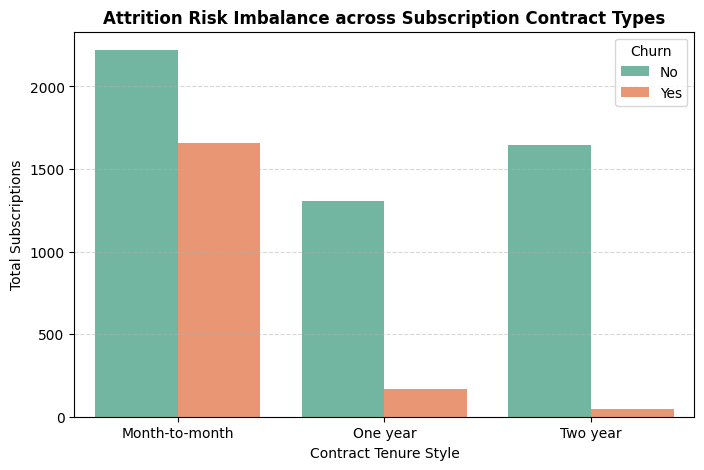

In [4]:
plt.figure(figsize=(8, 5))
# Generate a countplot comparing contracts against churn status
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')

plt.title('Attrition Risk Imbalance across Subscription Contract Types', fontsize=12, fontweight='bold')
plt.xlabel('Contract Tenure Style')
plt.ylabel('Total Subscriptions')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

/tmp/ipykernel_3462/330890316.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Pastel1')


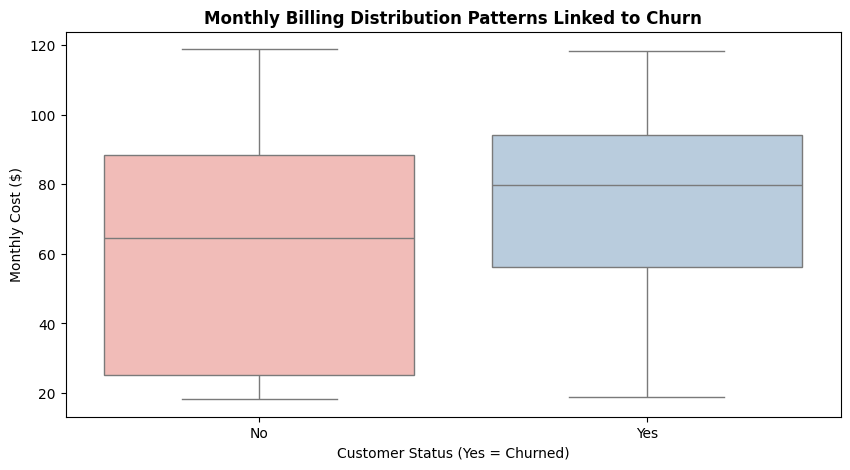

In [5]:
plt.figure(figsize=(10, 5))
# Generate a boxplot to evaluate the pricing distribution of churned users
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Pastel1')

plt.title('Monthly Billing Distribution Patterns Linked to Churn', fontsize=12, fontweight='bold')
plt.xlabel('Customer Status (Yes = Churned)')
plt.ylabel('Monthly Cost ($)')
plt.show()